#### Librerias

In [ ]:
# --- Análisis de Datos y Computación Numérica ---
import pandas as pd
import numpy as np

# --- Visualización de Datos ---
import seaborn as sns
import matplotlib.pyplot as plt

# --- Análisis Geoespacial ---
import geopandas as gpd
from shapely.geometry import Point

# --- Machine Learning con Scikit-Learn ---
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# --- Deep Learning con TensorFlow y Keras ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# --- Modelos Estadísticos ---
import statsmodels.api as sm

# --- Utilidades y Librerías Estándar ---
import math
import re
import requests
import zipfile
from io import StringIO
from IPython.display import Markdown, display

#### Carga de datos

In [ ]:
#csv_completo_github
#url = "https://raw.githubusercontent.com/guille1006/TFM/refs/heads/main/data/raw_data.csv" # Agosto
url = "https://raw.githubusercontent.com/guille1006/TFM/refs/heads/main/data2/total_data.csv"
df_datos = pd.read_csv(url)

In [ ]:
#Carpeta de ficheros_csv del drive
!gdown --folder -q https://drive.google.com/drive/folders/1GcfvHOr_N3NyKCmp6w1dX6HJ2JRfO1mD?usp=drive_link

Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=15IgvkaWSYSqCvkoEGNr_J7k3sD1DchBRuRwKC7CHgXo

but Gdown can't. Please check connections and permissions.


<table>
  <tr><th>Campo</th><th>Variable valida</th><th>Tipo</th><th>Descripción</th></tr>
  
  <tr><td colspan="4" align="center"><b> Dirección del inmueble</b></td></tr>
  <tr><td>latitude</td><td>Si</td><td>float</td><td>Coordenada de latitud</td></tr>
  <tr><td>longitude</td><td>Si</td><td>float</td><td>Coordenada de longitud</td></tr>
  <tr><td>showAddress</td><td>Si</td><td>bool</td><td>Muestra la dirección o no</td></tr>
  <tr><td>address</td><td>Si</td><td>category</td><td>Calle, número y país del inmueble</td></tr>
  <tr><td>neighborhood</td><td>Si</td><td>category</td><td>Vecindario donde está ubicado el inmueble</td></tr>
  <tr><td>district</td><td>Si</td><td>category</td><td>Distrito donde está ubicado el inmueble</td></tr>
  <tr><td>municipality</td><td>Si</td><td>category</td><td>Municipio donde está ubicado el inmueble</td></tr>
  <tr><td>province</td><td>Si</td><td>category</td><td>Provincia donde está ubicado el inmueble</td></tr>
  <tr><td>country</td><td>Si</td><td>category</td><td>País donde está ubicado el inmueble</td></tr>

  <tr><td colspan="4" align="center"><b> Características propias del inmueble</b></td></tr>
  <tr><td>rooms</td><td>Si</td><td>int</td><td>Número de habitaciones del inmueble</td></tr>
  <tr><td>size</td><td>Si</td><td>float</td><td>Metros cuadrados del inmueble</td></tr>
  <tr><td>bathrooms</td><td>Si</td><td>int</td><td>Número de baños</td></tr>
  <tr><td>exterior</td><td>Si</td><td>bool</td><td>Tiene parte exterior o no</td></tr>
  <tr><td>status</td><td>Si</td><td>category</td><td>Estado de la vivienda</td></tr>
  <tr><td>detailedType.subTypology</td><td>Si</td><td>category</td><td>Subtipo de inmueble</td></tr>
  <tr><td>detailedType.typology</td><td>Si</td><td>category</td><td>Tipo de inmueble</td></tr>
  <tr><td>floor</td><td>Si</td><td>int</td><td>Altura del piso</td></tr>
  <tr><td>hasLift</td><td>Si</td><td>bool</td><td>Tiene ascensor o no</td></tr>
  <tr><td>parkingSpace.hasParkingSpace</td><td>Si</td><td>bool</td><td>Tiene espacio para aparcar o no</td></tr>
  <tr><td>parkingSpace.isParkingSpaceIncludedInPrice</td><td>Si</td><td>bool</td><td>Está el precio del aparcamiento incluido en el precio o no</td></tr>
  <tr><td>parkingSpace.parkingSpacePrice</td><td>Si</td><td>float</td><td>Precio del espacio de aparcamiento</td></tr>
  <tr><td>price</td><td>Si</td><td>float</td><td>Precio del inmueble</td></tr>
  <tr><td>priceInfo.price.amount</td><td>Si</td><td>float</td><td>Precio del inmueble</td></tr>
  <tr><td>priceByArea</td><td>Si</td><td>float</td><td>Precio del metro cuadrado del inmueble</td></tr>
  <tr><td>priceInfo.price.currencySuffix</td><td>Si</td><td>category</td><td>Moneda del precio</td></tr>
  <tr><td>priceInfo.price.priceDropInfo.formerPrice</td><td>Si</td><td>float</td><td>Precio anterior del inmueble</td></tr>
  <tr><td>priceInfo.price.priceDropInfo.priceDropPercentage</td><td>Si</td><td>float</td><td>Porcentaje de rebaja del precio con respecto al precio anterior</td></tr>
  <tr><td>priceInfo.price.priceDropInfo.priceDropValue</td><td>Si</td><td>float</td><td>Cantidad del dinero que se ha rebajado con respecto al precio anterior</td></tr>
  <tr><td>newDevelopment</td><td>Si</td><td>bool</td><td>Es vivienda de nueva construcción o no</td></tr>
  <tr><td>newDevelopmentFinished</td><td>Si</td><td>bool</td><td>Es vivienda de nueva construcción terminada o no</td></tr>
  <tr><td>topNewDevelopment</td><td>Si</td><td>bool</td><td>Es un inmueble de nueva construcción o no</td></tr>
  <tr><td>highlight.groupDescription</td><td>Si</td><td>category</td><td></td></tr>

  <tr><td colspan="4" align="center"><b> Información relacionada con el anuncio</b></td></tr>
  <tr><td>description</td><td>Si</td><td>category</td><td>Descripción del anuncio, escrita por el dueño o la inmobiliaria</td></tr>
  <tr><td>numPhotos</td><td>Si</td><td>int</td><td>Número de fotos</td></tr>
  <tr><td>has360</td><td>Si</td><td>bool</td><td>Tiene imagen 360º del piso o no</td></tr>
  <tr><td>has3DTour</td><td>Si</td><td>bool</td><td>Tiene tour 3D o no</td></tr>
  <tr><td>hasVideo</td><td>Si</td><td>bool</td><td>Tiene video o no</td></tr>
  <tr><td>hasPlan</td><td>Si</td><td>bool</td><td>Tiene vista en plano o no</td></tr>
  <tr><td>hasStaging</td><td>Si</td><td>bool</td><td>Tiene visualización HomeStaging o no</td></tr>
  <tr><td>operation</td><td>Si</td><td>category</td><td>Tipo de operación: Venta, alquiler...</td></tr>
  <tr><td>suggestedTexts.subtitle</td><td>Si</td><td>object</td><td>Subtítulo del anuncio</td></tr>
  <tr><td>suggestedTexts.title</td><td>Si</td><td>object</td><td>Título del anuncio</td></tr>

  <tr><td colspan="4" align="center"><b> Información propia de Idealista</b></td></tr>
  <tr><td>externalReference</td><td>Si</td><td>object</td><td>Referencia externa usada por la página web de Idealista</td></tr>
  <tr><td>thumbnail</td><td>Si</td><td>object</td><td>Enlace a una imagen del anuncio</td></tr>
  <tr><td>topPlus</td><td>Si</td><td>bool</td><td>Pertenece al plan Plus o no</td></tr>
  <tr><td>highlight.groupDescription</td><td>Si</td><td>category</td><td>Tipo de grupo de descripcion</td></tr>
  <tr><td>url</td><td>Si</td><td>object</td><td>URL del anuncio</td></tr>
  <tr><td>notes</td><td>No</td><td>list</td><td>Lista vacía, no sabemos su uso</td></tr>
</table>


### Explicación de las variables no usadas:
- **Identificadores y Metadatos:** Variables como url, externalReference y thumbnail, que actúan como identificadores únicos o enlaces y no contienen información generalizable.

- **Variables Constantes:** Campos con un valor único para toda la muestra, como country (Spain), province (Madrid), operation (sale) y priceInfo.price.currencySuffix (EUR), que carecen de poder discriminatorio.

- **Variables Redundantes:** El campo priceInfo.price.amount, que es un duplicado exacto de la variable price.

- **Variables sin Varianza:** Columnas como notes y TopNewDevelopment, que se encontraron vacías, nulas o con un valor constante (False) en la totalidad de los registros.

#### EDA/ limpieza de datos

In [ ]:
print(df_datos.shape)
df_datos.describe().T

(26267, 49)


,count,mean,std,min,25%,50%,75%,max
bathrooms,26267.0,2.346442e+00,1.557807e+00,0.000000,1.000000e+00,2.000000e+00,3.000000e+00,2.900000e+01
latitude,26267.0,4.043244e+01,1.148277e-01,40.001899,4.038818e+01,4.042643e+01,4.046575e+01,4.110693e+01
longitude,26267.0,-3.717539e+00,1.638774e-01,-4.494274,-3.769397e+00,-3.698660e+00,-3.656073e+00,-3.071336e+00
numPhotos,26267.0,2.919210e+01,1.947732e+01,0.000000,1.600000e+01,2.600000e+01,3.900000e+01,1.900000e+02
parkingSpace.parkingSpacePrice,414.0,3.064735e+04,2.041348e+04,60.000000,1.500000e+04,2.800000e+04,4.000000e+04,1.000000e+05
price,26267.0,8.877257e+05,1.177656e+06,11000.000000,2.699450e+05,4.890000e+05,1.050000e+06,1.850000e+07
priceByArea,26267.0,5.173715e+03,3.526807e+03,2.000000,2.650000e+03,3.990000e+03,6.860000e+03,3.714300e+04
priceInfo.price.amount,26267.0,8.877257e+05,1.177656e+06,11000.000000,2.699450e+05,4.890000e+05,1.050000e+06,1.850000e+07
priceInfo.price.priceDropInfo.formerPrice,2806.0,6.127779e+05,5.973913e+05,32000.000000,2.500000e+05,3.990000e+05,7.500000e+05,7.500000e+06
priceInfo.price.priceDropInfo.priceDropPercentage,2806.0,4.614754e+00,3.116659e+00,1.000000,3.000000e+00,4.000000e+00,6.000000e+00,4.500000e+01


#### Eliminar duplicados

In [ ]:
# Eliminamos filas duplicadas (se eliminaron inicialmente en la obtencion inicial con la API, comprobación)
df_datos = df_datos.drop_duplicates()
print(df_datos.shape)

(26267, 49)


#### Valores nulos

In [ ]:
df_copy = df_datos.copy()

# Columnas no necesarias para la limpieza nulos, tras el analisis se eliminaran las necesarias
cols_to_drop = [
    'url', 'externalReference', 'thumbnail', 'propertyCode', 'description',
    'suggestedTexts.title', 'suggestedTexts.subtitle',
    'notes', 'address', 'country', 'province', 'operation',
    'priceInfo.price.amount',
    'priceInfo.price.currencySuffix',
    'topNewDevelopment', 'latitude', 'longitude'
]

df_copy.drop(columns=cols_to_drop, inplace=True)

# Estudiamos las columnas que presentan valores vacios tras el filtrado
df_nulos = df_copy[df_copy.columns[df_copy.isnull().any()]]

# Estudio de las variables nulas
info_types = pd.DataFrame(
    {"Tipo de columna": df_nulos.dtypes,
     "Valores únicos": df_nulos.nunique(dropna=False),
     "Valores nulos": df_nulos.isnull().sum()}
)

info_types

,Tipo de columna,Valores únicos,Valores nulos
detailedType.subTypology,object,14,17080
district,object,271,3450
exterior,object,3,7038
floor,object,45,7207
hasLift,object,3,6716
highlight.groupDescription,object,4,14883
neighborhood,object,198,10291
newDevelopmentFinished,object,3,23536
parkingSpace.hasParkingSpace,object,2,14374
parkingSpace.isParkingSpaceIncludedInPrice,object,3,14374


In [ ]:
#Separamos por formato
variables_num = df_nulos.select_dtypes(include=["number"])
variables_bool = df_nulos[[col for col in df_nulos.columns if df_nulos[col].nunique() < 3]]
variables_cat = df_nulos[[col for col in df_nulos.select_dtypes(include=["object", "category"]).columns if df_nulos[col].nunique() > 2]]

#### Variables booleanas nulas

In [ ]:
df_datos_1 = df_datos.copy()

| Variable                                 | Nº de Nulos | Tipo   | Estrategia de Imputación                   |
| :--------------------------------------- | :---------- | :----- | :----------------------------------------- |
| **exterior** | 7038        | object | Rellenar con `False` y convertir a binaria. |
| **hasLift** | 6716        | object | Rellenar con `False` y convertir a binaria. |
| **newDevelopmentFinished** | 23536       | object | Rellenar con `False` y convertir a binaria. |
| **parkingSpace.hasParkingSpace** | 14374       | object | Valores True o Nan. Rellenar nulos con False y convertirla a binaria. |
| **parkingSpace.isParkingSpaceIncludedInPrice**| 14374    | object | Nulos iguales a hasParkingSpace, repetir proceso. |

In [ ]:
df_datos_1[list(variables_bool.columns)] = (df_datos_1[list(variables_bool.columns)].fillna(False).astype(int))

/tmp/ipython-input-3374668481.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_datos_1[list(variables_bool.columns)] = (df_datos_1[list(variables_bool.columns)].fillna(False).astype(int))


#### Variables categóricas nulas

In [ ]:
df_datos_2 = df_datos_1.copy()

| Variable | Nº de Nulos | Tipo | Estrategia de Imputación |
| :--- | :--- | :--- | :--- |
| **detailedType.subTypology** | 17080 | object | Se imputa con una nueva categoría, 'Vacío', dada que no existe subtipolgia en ese caso. |
| **district** | 3450 | object | Se imputan los nulos mediante geolocalización inversa, utilizando las coordenadas para asignar el distrito correspondiente. |
| **floor** | 7207 | object | Se estandarizan los valores no numéricos (ej. 'bj', 'st') a sus equivalentes numéricos (0, -1).<br> Los nulos se tratan como planta baja (0) y se crea una variable `floor_cat` para capturar el efecto no lineal de estas categorías especiales. |
| **highlight.groupDescription** | 14883 | object | Se imputa con la categoría 'Vacio', asumiendo que la ausencia de valor implica la ausencia de una promoción. |
| **neighborhood** | 10291 | object | La columna se elimina debido a su alta cardinalidad y nulos, y se reemplaza por una feature binaria, `has_neighborhood`. |
| **status** | 597 | object | Se imputan los nulos como 'New development', basándose en la correlación observada con la variable `newDevelopment`, lo que resuelve una inconsistencia en los datos. |

In [ ]:
# detailedType.subTypology
df_datos_2["detailedType.subTypology"] = df_datos_2["detailedType.subTypology"].fillna("Vacío")

# District

# Ficheros de referencia
districts_shapefile = gpd.read_file("/content/Ficheros CSV/dist2024/dist2024.shp")
districts_map_df = pd.read_excel("/content/Ficheros CSV/distr24.xlsx").dropna()

# Identificar filas con distrito nulo
null_districts = df_datos_2[df_datos_2['district'].isna()]

if not null_districts.empty:
    # Convertir a GeoDataFrame para cruce espacial
    points_gdf = gpd.GeoDataFrame(
        null_districts,
        geometry=gpd.points_from_xy(null_districts.longitude, null_districts.latitude),
        crs="EPSG:4326"
    ).to_crs(districts_shapefile.crs)

    # Encontrar el distrito de cada punto mediante cruce espacial
    joined_gdf = gpd.sjoin(points_gdf, districts_shapefile, how="left", predicate='within')

    # Actualizar nulos en el DataFrame original
    df_datos_2.loc[joined_gdf.index, 'district'] = joined_gdf['DESCR']


# Crear el diccionario de mapeo
districts_map_df['cdtdistrito'] = districts_map_df['cdtdistrito'].astype(int).astype(str).str.zfill(5)
district_mapping_dict = dict(zip(districts_map_df['cdtdistrito'], districts_map_df['dspres']))

# Aplicar el mapeo para estandarizar los nombres de distrito
df_datos_2['district'] = df_datos_2['district'].astype(str).map(district_mapping_dict).fillna(df_datos_2['district'])

# Eliminar filas que no pudieron ser asignadas a un distrito
df_datos_2.dropna(subset=['district'], inplace=True)

# floor
def floor_function(row):
    x = str(row["floor"])
    res_cat = "Numerica"

    try:
        res_num = float(x.replace('+', ''))
    except (ValueError, TypeError):

        res_num = 0.0
        if row["detailedType.typology"] not in ["chalet", "countryHouse"]:
            res_cat = x

    # Aplicar el límite superior y devolver los dos valores
    res_num = min(res_num, 15.0)
    return pd.Series([res_num, res_cat])

df_datos_2[['floor', 'floor_cat']] = df_datos_2.fillna({'floor': 'Nulo'}).apply(floor_function, axis=1)

#groupDescription
df_datos_2['highlight.groupDescription'] = df_datos_2['highlight.groupDescription'].fillna("Vacío")

# Neighborhood
df_datos_2["has_neighborhood"] = (~df_datos_2["neighborhood"].isna()).astype(int)

# Status
df_datos_2["status"] = df_datos_2["status"].fillna("newdevelopment")

#### Variables numéricas nulas

In [ ]:
df_datos_3 = df_datos_2.copy()

| Variable                                        | Nº de Nulos | Tipo    | Estrategia de Imputación o Transformación                                                              |
| :---------------------------------------------- | :---------- | :------ | :----------------------------------------------------------------------------------------------------- |
| **parkingSpace.parkingSpacePrice** | 25853       | float64 | Imputar nulos con 0, en relacion con la variable hasParkingSpace y isParkingSpaceIncludedInPrice. <br>En el caso de falta de informacion  imputamos por la mediana |
| **priceInfo.price.priceDropInfo.formerPrice** | 23461       | float64 | Se elimará debido a su redundancia, tenemos la misma informacion con price y la nueva columna de descuento.                                |
| **priceInfo.price.priceDropInfo.priceDropPercentage**| 23461| float64 | Imputar nulos con 0, asumiendo que la ausencia de valor indica que no ha habido rebaja de precio.      |
| **priceInfo.price.priceDropInfo.priceDropValue**| 23461       | float64 | Imputar nulos con 0, y crear una nueva variable binaria a partir de sus datos.      |

In [ ]:
# parkingSpacePrice (uso de mediana, pocos valores como para imputar)
df_datos_3.loc[(df_datos_3['parkingSpace.parkingSpacePrice'].isna()) & (df_datos_3['parkingSpace.isParkingSpaceIncludedInPrice'] == False), 'parkingSpace.parkingSpacePrice'] = df_datos_3['parkingSpace.parkingSpacePrice'].median()
df_datos_3['parkingSpace.parkingSpacePrice'].fillna(0, inplace=True)

#priceDropPercentage y priceDropValue
df_datos_3['priceInfo.price.priceDropInfo.priceDropPercentage'] = df_datos_3['priceInfo.price.priceDropInfo.priceDropPercentage'].fillna(0.0)
df_datos_3['priceInfo.price.priceDropInfo.priceDropValue'] = df_datos_3['priceInfo.price.priceDropInfo.priceDropValue'].fillna(0.0)
df_datos_3['has_Discount'] = (df_datos_3['priceInfo.price.priceDropInfo.priceDropValue'] > 0).astype(int)

/tmp/ipython-input-4028854681.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_datos_3['parkingSpace.parkingSpacePrice'].fillna(0, inplace=True)


### Estudiar formato variables

In [ ]:
df_datos_4 = df_datos_3.copy()

In [ ]:
# Obtener información de las columnas
info_types = pd.DataFrame(
    {"Tipo de columna": df_datos_4.dtypes,
     "Valores únicos": df_datos_4.nunique(dropna=False),
     "Valores nulos": df_datos_4.isnull().sum()}
)
info_types

,Tipo de columna,Valores únicos,Valores nulos
address,object,8734,0
bathrooms,int64,19,0
country,object,1,0
description,object,21016,38
detailedType.subTypology,object,14,0
detailedType.typology,object,3,0
district,object,410,0
exterior,int64,2,0
externalReference,object,15225,6517
floor,float64,17,0


In [ ]:
# Variables a descartar
cols_to_drop = [
    'province',
    'country',
    'notes',
    'thumbnail',
    'externalReference',
    'priceInfo.price.currencySuffix',
    'url',
    "operation",
    "topNewDevelopment",
    "propertyCode",
    "address",
    "suggestedTexts.subtitle",
    'neighborhood',
    "suggestedTexts.title",
    'priceInfo.price.amount',
    'priceInfo.price.priceDropInfo.formerPrice'
]

# Eliminarlas del DataFrame
df_datos_4.drop(columns=cols_to_drop, inplace=True)

In [ ]:
df_datos_5 = df_datos_4.copy()

In [ ]:
categorical_cols = [
    'floor_cat', 'propertyType', 'municipality', 'district',
    'detailedType.typology', 'detailedType.subTypology',
    'highlight.groupDescription', 'status'
]
numeric_cols = [
    'floor', 'price', 'size', 'rooms', 'bathrooms', 'latitude', 'longitude',
    'priceByArea', 'priceInfo.price.priceDropInfo.priceDropValue',
    'priceInfo.price.priceDropInfo.priceDropPercentage',
    'parkingSpace.parkingSpacePrice', 'numPhotos'
]
binary_cols = [
    'showAddress', 'hasVideo', 'newDevelopment', 'newDevelopmentFinished',
    'hasPlan', 'has3DTour', 'has360', 'hasStaging', 'topPlus', 'exterior',
    'hasLift', 'parkingSpace.hasParkingSpace',
    'parkingSpace.isParkingSpaceIncludedInPrice', 'has_neighborhood', 'has_Discount'
]

# Convertir columnas binarias a formato numérico.
df_datos_5[binary_cols] = df_datos_5[binary_cols].replace(
    {True: 1, 'True': 1, False: 0, 'False': 0}
)

# Convertir a tipo categórico
df_datos_5[categorical_cols] = df_datos_5[categorical_cols].astype('object')

/tmp/ipython-input-965622315.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_datos_5[binary_cols] = df_datos_5[binary_cols].replace(


In [ ]:
df_datos_6 = df_datos_5.copy()

In [ ]:
#Establecemos las variables numéricas y las categóricas
variables_numericas = df_datos_6.select_dtypes(include=np.number).columns.tolist()
variables_categoricas = df_datos_6.select_dtypes(exclude=np.number).columns.drop('description').tolist()

#### Estudio de las variables categoricas


| Variable                   | Tipo     | Estrategia de Tratamiento                                |
| :------------------------- | :------- | :------------------------------------------------------- |
| **detailedType.subTypology** | category | Agrupación de categorías poco representadas (< 0.65%).   |
| **detailedType.typology** | category | Distribución correcta.                                   |
| **district** | category | Agrupación de categorías poco representadas (< 0.065 %). |
| **highlight.groupDescription** | category | Distribución correcta.                                   |
| **municipality** | category | Agrupación de categorías poco representadas (< 0.5 %).   |
| **propertyType** | category | Distribución correcta.                                   |
| **status** | category | Distribución correcta.                                   |
| **floor_cat** | category | Cambios realizados anteriormente.     



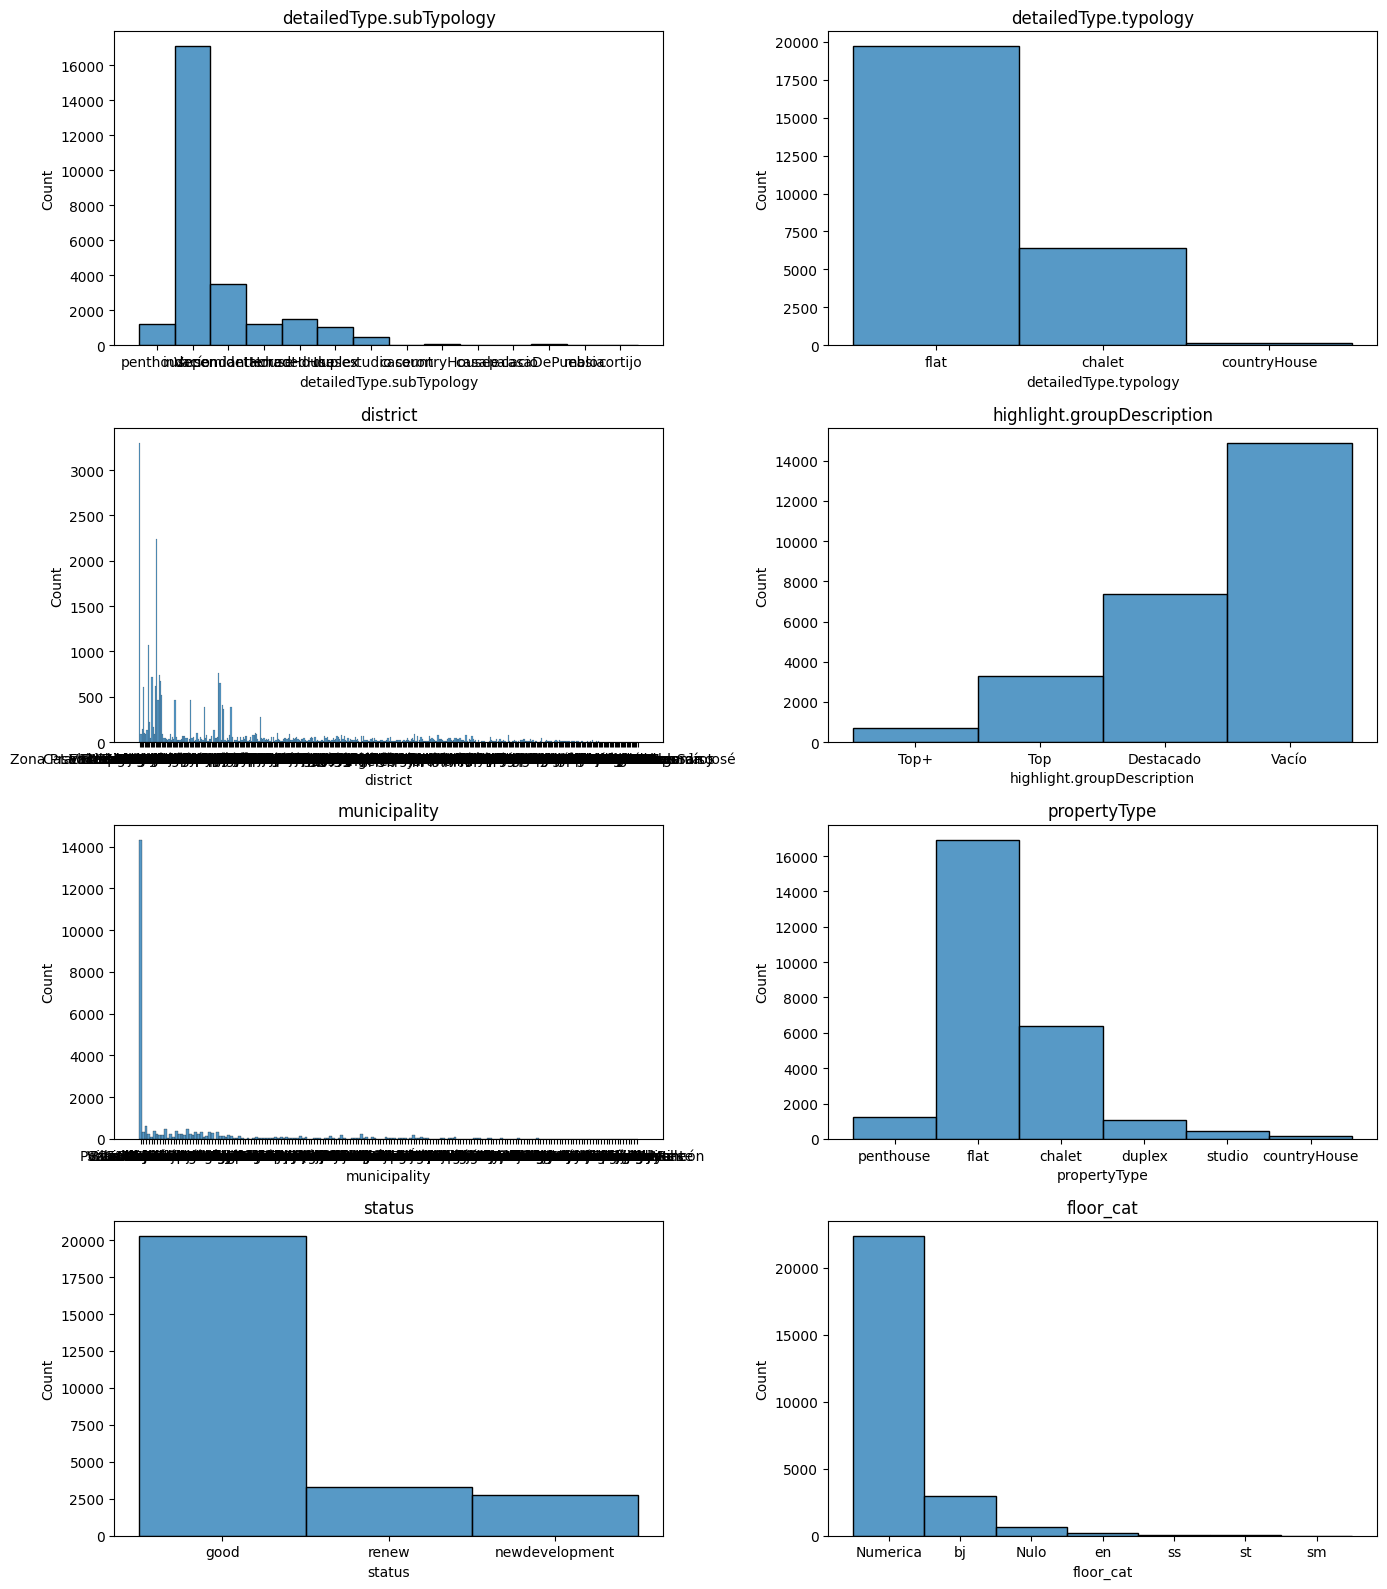

In [ ]:
# Estudio variables categóricas
n = len(variables_categoricas)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, variables_categoricas):
    sns.histplot(data=df_datos_6, x=col, bins=20, ax=ax)
    ax.set_title(col)
for ax in axes[len(variables_categoricas):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [ ]:
# Frecuencia absoluta & Porcentaje
for i in variables_categoricas:
  conteo = df_datos_6[i].value_counts()
  porcentaje = df_datos_6[i].value_counts(normalize=True)
  #display(pd.DataFrame({"frecuencia": conteo, "porcentaje %": porcentaje}))

In [ ]:
# detailedType.subTypology
umbral_prop = 0.002234

# Categorías cuya frecuencia es menor que el umbral
frecuencias = df_datos_6["detailedType.subTypology"].value_counts(normalize=True)
categorias_a_agrupar = frecuencias[frecuencias < umbral_prop].index

# Reemplazar esas categorías infrecuentes con el valor "OTROS"
df_datos_6.loc[df_datos_6["detailedType.subTypology"].isin(categorias_a_agrupar), "detailedType.subTypology"] = "OTROS"

In [ ]:
# municipality

umbral_prop = 0.005

frecuencias = df_datos_6["municipality"].value_counts(normalize=True)
municipios_a_agrupar = frecuencias[frecuencias < umbral_prop].index

df_datos_6.loc[df_datos_6["municipality"].isin(municipios_a_agrupar), "municipality"] = "OTROS"

In [ ]:
# District
umbral_prop = 0.00065

frecuencias = df_datos_6["district"].value_counts(normalize=True)
distritos_a_agrupar = frecuencias[frecuencias < umbral_prop].index

df_datos_6.loc[df_datos_6["district"].isin(distritos_a_agrupar), "district"] = "OTROS"

La cardinalidad de las variables categoricas sigue siendo muy alta en algunas variables incluso después de agrupar por menos representadas. Podemos hacer un embedding para no hacer un OHE, que aumentaría extremadamente la dimensionalidad. Si al final se usa OHE precindiriamos de ellas.

#### Estudio de las variables numéricas

In [ ]:
df_datos_7 = df_datos_6.copy()

| Variable                                 | Tipo      | Estrategia de Tratamiento                                                       |
| :--------------------------------------- | :-------- | :--------------------------------------------------------------------------------------------------------- |
| **floor** | Numérica  | Cambios ya realizados.|
| **price** | Numérica  | Detectar outliers según los dos criterios de la función e imputar nans.  |
| **size** | Numérica  | Detectar outliers según los dos criterios de la función e imputar nans.|
| **rooms** | Categórica| Cambio de int64 a category, tramificación para obtener una distribución más uniforme.                    |
| **bathrooms** | Categórica| Cambio de int64 a category, tramificación para obtener una distribución más uniforme.                    |
| **latitude** / **longitude** | Numérica  | Sin necesidad de cambios.      |
| **priceByArea** | Numérica  | Detectar outliers según los dos criterios de la función e imputar nans.                                      |
| **parkingSpace.parkingSpacePrice** | Numérica  | Sin necesidad de cambios.|
| **numPhotos** | Categórica| Cambio de int64 a category, tramificación para obtener una distribución más uniforme.                    |
| **showAddress** | Binaria   | Sin necesidad de cambios.                                                                            |
| **hasVideo** | Binaria   | Sin necesidad de cambios.                                                                            |
| **newDevelopment** | Binaria   | Sin necesidad de cambios.                                                                            |
| **newDevelopmentFinished** | Binaria   | Sin necesidad de cambios.                                                                            |
| **hasPlan** | Binaria   | Sin necesidad de cambios.                                                                            |
| **has3DTour** | Binaria   | Sin necesidad de cambios.                                                                            |
| **has360** | Binaria   | Sin necesidad de cambios.                                                                            |
| **hasStaging** | Binaria   | Clase minoritaria poco representada (< 0.05). Se evaluará su eliminación.                               |
| **topPlus** | Binaria   | Clase minoritaria poco representada (< 0.05). Se evaluará su eliminación.                               |
| **exterior** | Binaria   | Sin necesidad de cambios.                                                                            |
| **hasLift** | Binaria   | Sin necesidad de cambios.                                                                            |
| **parkingSpace.hasParkingSpace** | Binaria   | Sin necesidad de cambios.                                                                            |
| **parkingSpace.isParkingSpaceIncludedInPrice** | Binaria   | Sin necesidad de cambios.                                                                            |
| **has_neighborhood** | Binaria   | Feature de ingeniería ya creada. Se mantiene.                                                       |
| **has_Discount** | Binaria   | Feature de ingeniería ya creada. Se mantiene.

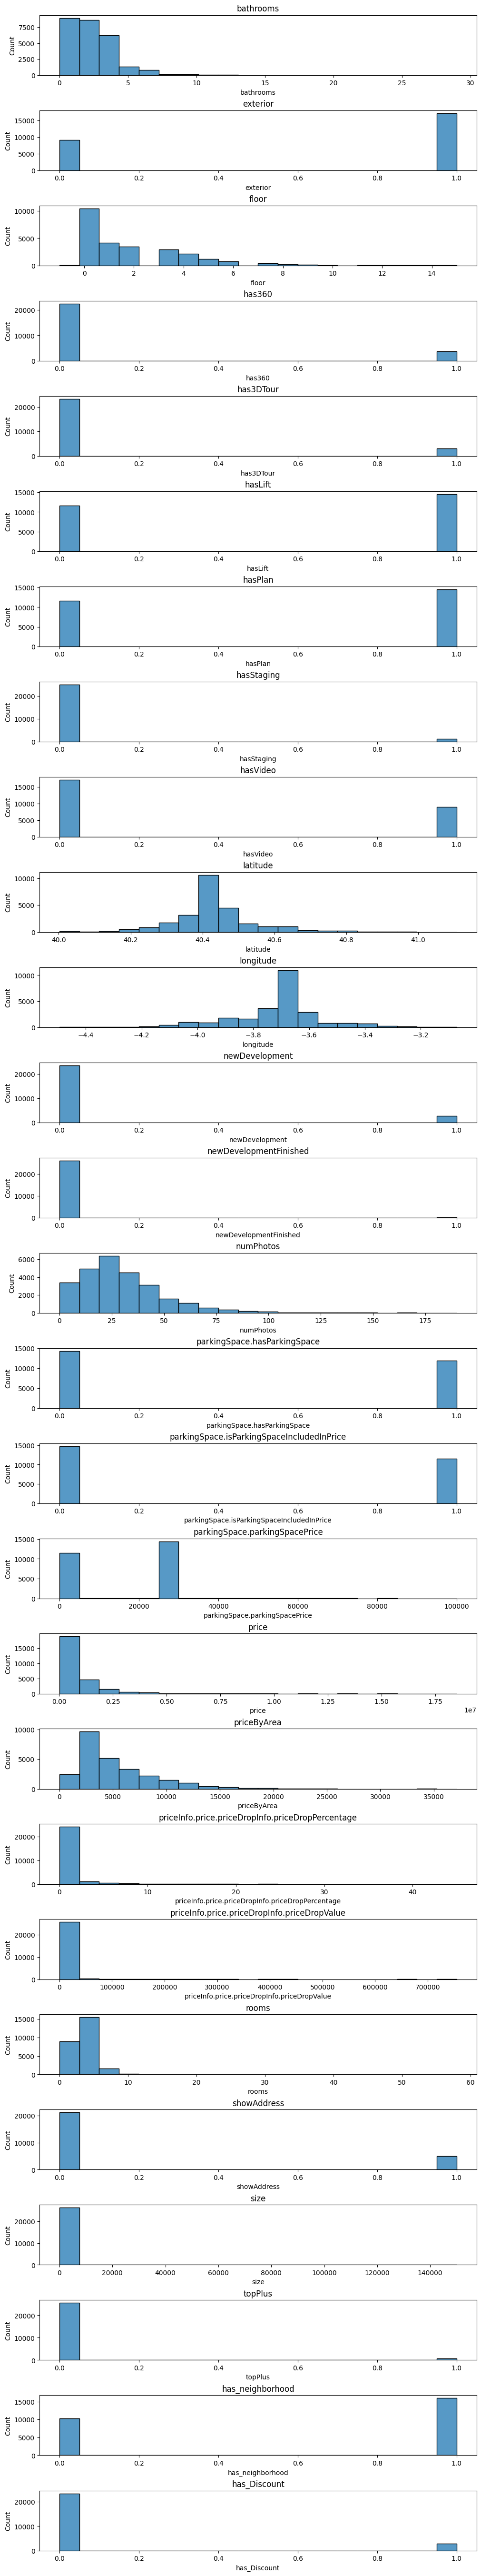

In [ ]:
n = len(variables_numericas)
fig, axes = plt.subplots(n, 1, figsize=(10, 2 * n), constrained_layout=True)

for ax, col in zip(axes, variables_numericas):
    sns.histplot(data=df_datos_7, x=col, bins=20, ax=ax)
    ax.set_title(col)

plt.show()

In [ ]:
# Binning para variables numéricas con sentido categórico
bins_labels = {
    'numPhotos': {
        'bins': [0, 5, 10, 20, 30, 50, 60, float('inf')],
        'labels': ['0-5', '5-10', '10-20', '20-30', '30-50', '50-60', '+60']
    },
    'rooms': {
        'bins': [0, 2, 3, 4, 5, 6, float('inf')],
        'labels': ['1', '2', '3', '4', '5', '+5']
    },
    'bathrooms': {
        'bins': [0, 2, 3, 4, 5, float('inf')],
        'labels': ['1', '2', '3', '4', '+4']
    }
}

for col, params in bins_labels.items():
    df_datos_7[col] = pd.cut(df_datos_7[col], bins=params['bins'], labels=params['labels'], right=False)

variables_numericas = df_datos_7.select_dtypes(include=np.number).columns.tolist()
variables_categoricas = df_datos_7.select_dtypes(exclude=np.number).columns.drop('description').tolist()

In [ ]:
#Tratamiento de outliers

def tratar_outliers(df, columnas_a_tratar, features_para_imputar):
    """
    Detecta outliers, los reemplaza por NaN y los imputa usando RandomForest,
    devolviendo un nuevo DataFrame limpio.
    """
    df_procesado = df.copy()

    # Detección y Reemplazo de Outliers
    for col in columnas_a_tratar:
        if abs(df_procesado[col].skew()) < 1:
            criterio1 = abs((df_procesado[col] - df_procesado[col].mean()) / df_procesado[col].std()) > 3
        else:
            mad = sm.robust.mad(df_procesado[col].dropna())
            criterio1 = abs((df_procesado[col] - df_procesado[col].median()) / mad) > 8

        q1, q3 = df_procesado[col].quantile([0.25, 0.75])
        criterio2 = ~df_procesado[col].between(q1 - 3 * (q3 - q1), q3 + 3 * (q3 - q1))
        df_procesado.loc[criterio1 & criterio2, col] = np.nan

    # Imputación de Nulos con RandomForest
    for col in columnas_a_tratar:
        if df_procesado[col].isnull().sum() == 0:
            continue

        # Preparar los datos para el modelo de imputación
        train = df_procesado[df_procesado[col].notnull()]
        test = df_procesado[df_procesado[col].isnull()]

        X_train = train[features_para_imputar].fillna(train[features_para_imputar].mean())
        y_train = train[col]
        X_test = test[features_para_imputar].fillna(train[features_para_imputar].mean())

        # Entrenar y predecir
        rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X_train, y_train)
        predictions = rf.predict(X_test)

        # Asignar las predicciones de vuelta al DataFrame
        df_procesado.loc[df_procesado[col].isnull(), col] = predictions

    return df_procesado

features_para_imputar = [
    'size', 'latitude', 'longitude', 'floor', 'exterior', 'hasLift',
    'parkingSpace.hasParkingSpace', 'parkingSpace.isParkingSpaceIncludedInPrice',
    'parkingSpace.parkingSpacePrice', 'newDevelopment', 'newDevelopmentFinished',
    'has_Discount', 'has_neighborhood', 'hasVideo', 'hasPlan', 'has3DTour',
    'has360', 'hasStaging', 'topPlus', 'showAddress'
]

df_datos_7 = tratar_outliers(
    df_datos_7,
    columnas_a_tratar=['price', 'priceByArea', 'size'],
    features_para_imputar=features_para_imputar
)

In [ ]:
# Calcular los descriptivos base
descriptivos_num = df_datos_7[variables_numericas].describe().T

# Calcular estadísticos adicionales de forma eficiente con .agg()
additional_stats = df_datos_7[variables_numericas].agg(['skew', 'kurt', lambda x: x.max() - x.min()]).T
additional_stats.rename(columns={'skew': 'Asimetria', 'kurt': 'Kurtosis', '<lambda>': 'Rango'}, inplace=True)

descriptivos_num = descriptivos_num.join(additional_stats)

# Mostrar la tabla de descriptivos completa
descriptivos_num

,count,mean,std,min,25%,50%,75%,max,Asimetria,Kurtosis,Rango
exterior,26261.0,0.651955,0.476359,0.000000,0.000000,1.000000,1.000000e+00,1.000000e+00,-0.638035,-1.593033,1.000000e+00
floor,26261.0,1.820152,2.193319,-1.000000,0.000000,1.000000,3.000000e+00,1.500000e+01,1.582561,3.415737,1.600000e+01
has360,26261.0,0.142531,0.349600,0.000000,0.000000,0.000000,0.000000e+00,1.000000e+00,2.045172,2.182897,1.000000e+00
has3DTour,26261.0,0.113743,0.317505,0.000000,0.000000,0.000000,0.000000e+00,1.000000e+00,2.433266,3.921080,1.000000e+00
hasLift,26261.0,0.555767,0.496890,0.000000,0.000000,1.000000,1.000000e+00,1.000000e+00,-0.224482,-1.949756,1.000000e+00
hasPlan,26261.0,0.555767,0.496890,0.000000,0.000000,1.000000,1.000000e+00,1.000000e+00,-0.224482,-1.949756,1.000000e+00
hasStaging,26261.0,0.048285,0.214371,0.000000,0.000000,0.000000,0.000000e+00,1.000000e+00,4.214657,15.764532,1.000000e+00
hasVideo,26261.0,0.343361,0.474840,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00,0.659806,-1.564775,1.000000e+00
latitude,26261.0,40.432479,0.114802,40.001899,40.388239,40.426433,4.046575e+01,4.110693e+01,0.501427,3.192490,1.105029e+00
longitude,26261.0,-3.717432,0.163703,-4.494274,-3.769262,-3.698649,-3.656051e+00,-3.071336e+00,-0.549226,2.613252,1.422938e+00


In [ ]:
# Comprobar las discrepancias entre las columnas clasificadas y las reales
columnas_clasificadas = set(variables_categoricas + variables_numericas)
columnas_reales = set(df_datos_7.columns)
discrepancias = columnas_reales.symmetric_difference(columnas_clasificadas)

# La única discrepancia permitida es la columna 'description'
discrepancia_esperada = {'description'}

if not discrepancias or discrepancias == discrepancia_esperada:
    print("Verificación exitosa: Todas las columnas están clasificadas correctamente.")
    if discrepancias:
        print("(Nota: La columna 'description' no ha sido clasificada, como se esperaba para su posterior tratamiento con embeddings).\n")

    print("Variables categóricas:")
    print(variables_categoricas, "\n")
    print("Variables numéricas:")
    print(variables_numericas, "\n")
    print("Valores nulos restantes por columna:")
    print(df_datos_7.isnull().sum())
else:
    print(" Discrepancias inesperadas encontradas:")
    # Identificar las discrepancias inesperadas
    faltantes = columnas_reales - columnas_clasificadas - discrepancia_esperada
    sobrantes = columnas_clasificadas - columnas_reales - discrepancia_esperada
    if faltantes:
        print(f" - Columnas en el DataFrame no clasificadas: {faltantes}")
    if sobrantes:
        print(f" - Columnas clasificadas que ya no están en el DataFrame: {sobrantes}")

Verificación exitosa: Todas las columnas están clasificadas correctamente.
(Nota: La columna 'description' no ha sido clasificada, como se esperaba para su posterior tratamiento con embeddings).

Variables categóricas:
['bathrooms', 'detailedType.subTypology', 'detailedType.typology', 'district', 'highlight.groupDescription', 'municipality', 'numPhotos', 'propertyType', 'rooms', 'status', 'floor_cat'] 

Variables numéricas:
['exterior', 'floor', 'has360', 'has3DTour', 'hasLift', 'hasPlan', 'hasStaging', 'hasVideo', 'latitude', 'longitude', 'newDevelopment', 'newDevelopmentFinished', 'parkingSpace.hasParkingSpace', 'parkingSpace.isParkingSpaceIncludedInPrice', 'parkingSpace.parkingSpacePrice', 'price', 'priceByArea', 'priceInfo.price.priceDropInfo.priceDropPercentage', 'priceInfo.price.priceDropInfo.priceDropValue', 'showAddress', 'size', 'topPlus', 'has_neighborhood', 'has_Discount'] 

Valores nulos restantes por columna:
bathrooms                                             0
descript

### Guardar datos limpios

In [ ]:
df_datos_7.to_csv("datos_Idealista_limpios.csv", index=False, encoding="utf-8")